<a href="https://colab.research.google.com/github/ryanecole2-lang/Machine-Learning-With-Python-Bootcamp/blob/main/EDA_and_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading and Preserving

In [2]:
import pandas as pd

#1. The data Link
url ="https://raw.githubusercontent.com/ryanecole2-lang/Machine-Learning-With-Python-Bootcamp/refs/heads/main/market_dirty.csv"

#2. read the data
df =pd.read_csv(url)

#3. keep a raw copy  comparison
df_raw =df.copy()
#. look as the first rows
print(df.head())

         date  rainfall_mm  transport_cost_lrd  supply_bags  price_lrd  \
0  2026-04-01         17.7              2935.0          158     3261.0   
1  2026-04-02         19.4              3843.0           45     4182.0   
2  2026-04-03         50.9              2655.0          218     2941.0   
3  2026-04-04          8.2              2268.0          221     4131.0   
4  2026-04-05         42.5              2369.0          220     3268.0   

   scarcity_alert  
0            True  
1            True  
2            True  
3           False  
4            True  


Asking Data Question

In [3]:
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                40 non-null     object 
 1   rainfall_mm         40 non-null     float64
 2   transport_cost_lrd  40 non-null     float64
 3   supply_bags         40 non-null     int64  
 4   price_lrd           38 non-null     float64
 5   scarcity_alert      40 non-null     bool   
dtypes: bool(1), float64(3), int64(1), object(1)
memory usage: 1.7+ KB


,0
date,0
rainfall_mm,0
transport_cost_lrd,0
supply_bags,0
price_lrd,2
scarcity_alert,0


Removing Blank Prices

In [4]:
# Drop rows where price is empty
df = df.dropna(subset=['price_lrd'])

# See how many records survived
print(f'original: {len(df_raw)}')
print(f'clean: {len(df)}')

original: 40
clean: 38


Filling in the Gaps

In [5]:
# 1: find the middle (mean) transport cost
middle_cost =df['transport_cost_lrd'].mean()

#2. Fill in the blank cells with this middle value
df['transport_cost_lrd'] = df['transport_cost_lrd'].fillna(middle_cost)

#3.verify: the blank should now be 0
print(df[f'price_lrd']. isna(). sum)

<bound method Series.sum of 0     False
1     False
2     False
3     False
4     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
Name: price_lrd, dtype: bool>


**The "Speed Limit"**

In [6]:
 Limit = df['price_lrd'].quantile(0.95)

# Bring the crazy spikes down to the limit
df['price_lrd'] = df['price_lrd'].clip(upper=Limit)

,price_lrd
0,3261.0
1,4182.0
2,2941.0
3,4131.0
4,3268.0
6,3848.0
7,3015.0
8,3539.0
9,3291.0
10,2835.0


**Comparing Before and After**

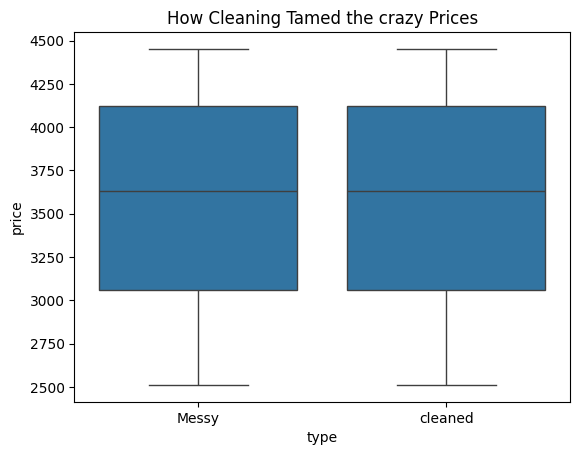

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a Dataframe for df_raw prices with a 'type' column
df_raw_plot = pd.DataFrame({
    'price': df_raw['price_lrd'],
    'type': 'Messy'
})

# Create a Dataframe for df_(cleaned) prices with a 'type' column
df_cleaned_plot = pd.DataFrame({
    'price': df['price_lrd'],
    'type': 'cleaned'
    })
# Concatenate these two dataframes, ignoring their original indices, to create long-form data
plot_data = pd.concat([df_raw_plot, df_cleaned_plot], ignore_index=True)

sns.boxplot(x='type', y='price', data=plot_data)
plt.title('How Cleaning Tamed the crazy Prices')
plt.show()

**Step 1: Regression**

In [18]:
# Verbatim Step 1 Code Block
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

url="https://raw.githubusercontent.com/ryanecole2-lang/Machine-Learning-With-Python-Bootcamp/refs/heads/main/gari_price_data.csv"
df=pd.read_csv(url)

# Use our model-ready dataset (already loaded as 'df')
print(df.head())
print(df.shape)

   rainfall_mm  transport_cost_lrd  supply_bags  price_next_day_lrd
0         18.7                2702          111              3179.0
1         47.5                2401           86              3178.0
2         36.6                2729          148              3060.0
3         29.9                2161          153              2851.0
4          7.8                2201           84              2907.0
(50, 4)


**Features Selection**

In [20]:
#Verbatim Step 2 Code Block
X = df[['rainfall_mm','transport_cost_lrd', 'supply_bags']]
y = df['price_next_day_lrd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

Training rows: 40
Test rows: 10


**Training and Prediction**

In [21]:
#Verbatim Step 3 Code Block
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Interception: ', round(model.intercept_, 2))
print('coefficients:', dict(zip(X.columns, np.round(model.coef_, 2))))

Interception:  2464.17
coefficients: {'rainfall_mm': np.float64(4.3), 'transport_cost_lrd': np.float64(0.3), 'supply_bags': np.float64(-2.35)}
